# 02 - Retrieval benchmark: seven configurations, one honest ranking

This notebook reads the runs produced by
`python -m src.evaluation.run_retrieval_eval` and asks three questions:

1. Does the implementation agree with published BEIR numbers? (If not,
   nothing below means anything.)
2. Which configuration actually wins?
3. Are the gaps large enough that 648 queries can resolve them?

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_split
from src.evaluation.ir_metrics import evaluate_run, ndcg_at_k

sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parent
corpus, queries, qrels = load_split("test")

metrics = json.loads((ROOT / "output/reports/retrieval_metrics.json").read_text())
LABELS = {
    "random": "Random (floor)",
    "bm25": "BM25",
    "dense_minilm": "Dense: all-MiniLM-L6-v2",
    "dense_bge": "Dense: bge-base-en-v1.5",
    "hybrid": "Hybrid: RRF(BM25, bge)",
    "rerank_hybrid": "Hybrid + ms-marco reranker",
    "rerank_dense": "Dense + ms-marco reranker",
    "rerank_dense_bge": "Dense + bge reranker",
    "rerank_bm25": "BM25 + ms-marco reranker",
}
df = pd.DataFrame([
    {"configuration": LABELS[k], "nDCG@10": v["ndcg@10"], "Recall@10": v["recall@10"],
     "Recall@100": v["recall@100"], "MRR@10": v["mrr@10"]}
    for k, v in metrics.items()
]).sort_values("nDCG@10", ascending=False).reset_index(drop=True)
df

,configuration,nDCG@10,Recall@10,Recall@100,MRR@10
0,Dense: bge-base-en-v1.5,0.406231,0.481352,0.741472,0.485444
1,Dense + ms-marco reranker,0.385061,0.470740,0.741472,0.454181
2,Hybrid + ms-marco reranker,0.374335,0.453044,0.718353,0.444615
3,Dense: all-MiniLM-L6-v2,0.368671,0.441306,0.706057,0.445122
4,"Hybrid: RRF(BM25, bge)",0.358793,0.435913,0.718353,0.431467
5,Dense + bge reranker,0.353979,0.439234,0.741472,0.422994
6,BM25 + ms-marco reranker,0.323910,0.380145,0.509056,0.401132
7,BM25,0.237362,0.300870,0.509056,0.293235
8,Random (floor),0.000000,0.000000,0.000643,0.000000


## 1. Is the implementation right?

A benchmark result is worthless if the harness is subtly broken, and a
broken harness usually still produces plausible-looking numbers. The check
here is external: BEIR publishes results for both BM25 and
`bge-base-en-v1.5` on this exact split.

In [2]:
published = {"bm25": 0.236, "dense_bge": 0.406}
for name, expected in published.items():
    got = metrics[name]["ndcg@10"]
    print(f"{LABELS[name]:28s} ours={got:.4f}  published={expected:.3f}  "
          f"diff={got - expected:+.4f}")

BM25                         ours=0.2374  published=0.236  diff=+0.0014
Dense: bge-base-en-v1.5      ours=0.4062  published=0.406  diff=+0.0002


Both land within 0.002 of the published values. Small residual differences
are expected -- BEIR's BM25 runs on Elasticsearch with its own analyzer,
this one runs on `rank_bm25` with the stoplist in `src/retrieval/bm25.py` --
but nothing here is off by an amount that would change a conclusion.

## 2. Which configuration wins?

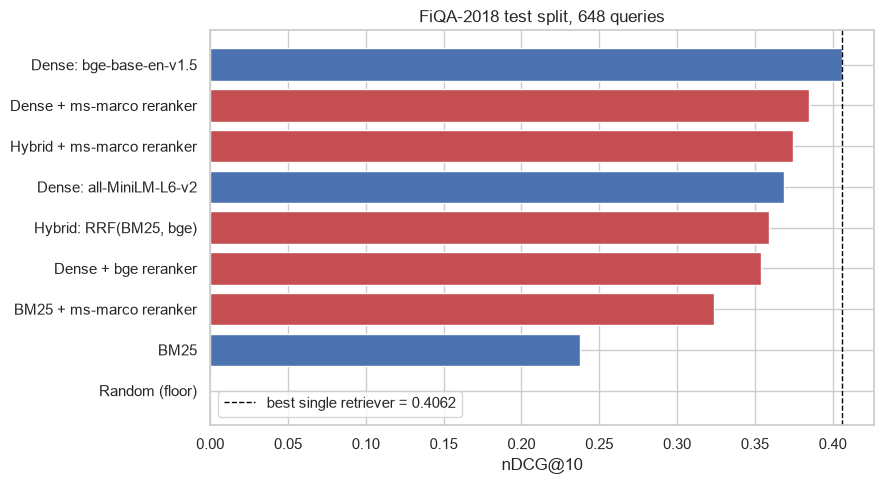

In [3]:
order = df.sort_values("nDCG@10")
colors = ["#C44E52" if "rerank" in k or "Hybrid" in k else "#4C72B0"
          for k in order["configuration"]]
plt.figure(figsize=(9, 5))
plt.barh(order["configuration"], order["nDCG@10"], color=colors)
best = metrics["dense_bge"]["ndcg@10"]
plt.axvline(best, color="black", ls="--", lw=1,
            label=f"best single retriever = {best:.4f}")
plt.xlabel("nDCG@10"); plt.title("FiQA-2018 test split, 648 queries")
plt.legend(); plt.tight_layout(); plt.show()

The winner is the plain dense retriever, with nothing bolted on top.

Every configuration that adds a component -- RRF fusion with BM25, or a
cross-encoder reranker, or both -- lands *below* it. That is the opposite
of the standard RAG recipe, in which fusion and reranking are presented as
strict improvements.

## 3. Is the reranker broken, or is it just outclassed?

This distinction matters. "Reranking hurts" is a claim about reranking;
"our reranker was wired wrong" is a claim about this notebook. The way to
tell them apart is to apply the same reranker to a *weak* first stage,
where reranking is known to produce large gains.

In [4]:
diag = pd.DataFrame([
    {"first stage": "BM25", "before": metrics["bm25"]["ndcg@10"],
     "after reranking": metrics["rerank_bm25"]["ndcg@10"]},
    {"first stage": "Hybrid RRF", "before": metrics["hybrid"]["ndcg@10"],
     "after reranking": metrics["rerank_hybrid"]["ndcg@10"]},
    {"first stage": "Dense (bge)", "before": metrics["dense_bge"]["ndcg@10"],
     "after reranking": metrics["rerank_dense"]["ndcg@10"]},
])
diag["change"] = diag["after reranking"] - diag["before"]
diag["relative"] = (diag["change"] / diag["before"]).map("{:+.1%}".format)
diag

,first stage,before,after reranking,change,relative
0,BM25,0.237362,0.323910,0.086547,+36.5%
1,Hybrid RRF,0.358793,0.374335,0.015542,+4.3%
2,Dense (bge),0.406231,0.385061,-0.021171,-5.2%


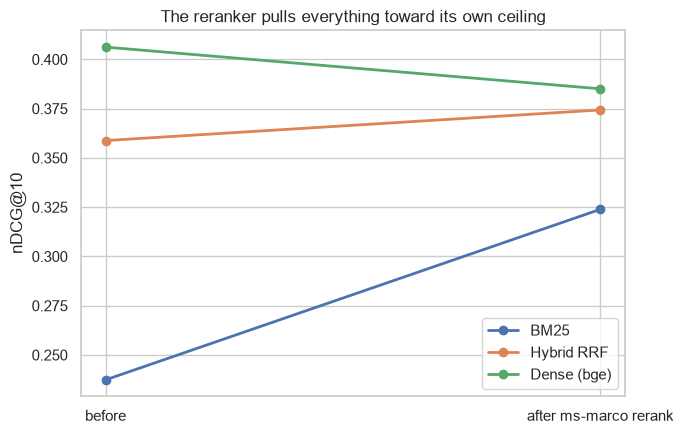

In [5]:
plt.figure(figsize=(7, 4.5))
for _, r in diag.iterrows():
    plt.plot(["before", "after ms-marco rerank"], [r["before"], r["after reranking"]],
             marker="o", lw=2, label=r["first stage"])
plt.ylabel("nDCG@10")
plt.title("The reranker pulls everything toward its own ceiling")
plt.legend(); plt.tight_layout(); plt.show()

The reranker works exactly as advertised on a weak first stage: BM25 goes
from 0.2374 to 0.3239, a 36% relative gain. It is not miswired.

What it cannot do is exceed its own quality ceiling. `ms-marco-MiniLM-L-6-v2`
was trained on MS MARCO web search, and on financial forum text it tops out
around nDCG@10 = 0.32-0.39. Applied to a retriever already at 0.4062, it
sorts good results into a worse order.

This is the same failure mode as Project 1, where an off-the-shelf
DistilBERT sentiment model scored *below* a rule-based baseline on
financial text. General-purpose components transfer badly to this domain,
and the only way to find out is to measure them against the thing they are
supposed to improve.

## 4. Can 648 queries resolve these gaps?

In [6]:
sig = json.loads((ROOT / "output/reports/retrieval_significance.json").read_text())
sig_df = pd.DataFrame([
    {"comparison": k.replace("_vs_", "  vs  "),
     "delta nDCG@10": v["mean_difference"],
     "95% CI": f"[{v['ci_low']:+.4f}, {v['ci_high']:+.4f}]",
     "p": v["p_value"],
     "significant": "yes" if v["p_value"] < 0.05 else "NO"}
    for k, v in sig.items()
])
sig_df

,comparison,delta nDCG@10,95% CI,p,significant
0,dense_bge vs bm25,0.168869,"[+0.1438, +0.1936]",0.0000,yes
1,dense_bge vs dense_minilm,0.037560,"[+0.0193, +0.0560]",0.0000,yes
2,hybrid vs dense_bge,-0.047438,"[-0.0673, -0.0277]",0.0000,yes
3,rerank_dense vs dense_bge,-0.021171,"[-0.0380, -0.0043]",0.0146,yes
4,rerank_dense_bge vs dense_bge,-0.052253,"[-0.0718, -0.0330]",0.0000,yes
5,rerank_bm25 vs bm25,0.086547,"[+0.0684, +0.1047]",0.0000,yes


Every comparison clears p < 0.05, most of them by a wide margin. The
narrowest is `rerank_dense vs dense_bge` at p = 0.015 -- real, but the one
result here that a different sample of 648 questions could plausibly soften.

## 5. Where does the winning retriever still fail?

An aggregate of 0.4062 hides the shape of the failures. Half the value of a
benchmark is knowing which queries it loses on.

complete misses (nDCG@10 = 0)      : 198  (30.6%)
perfect                            :  90  (13.9%)
partial                            : 360


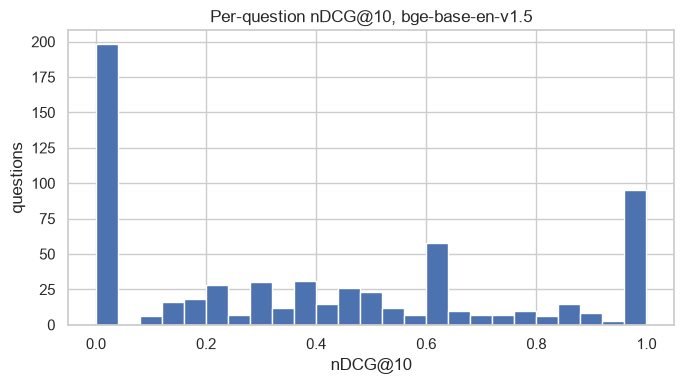

In [7]:
def load_run(name):
    with open(ROOT / "data/processed/runs" / f"{name}.json") as f:
        return {q: [d for d, _ in v] for q, v in json.load(f).items()}

best_run = load_run("dense_bge")
per_q = {qid: ndcg_at_k(best_run.get(qid, []), qrels[qid], 10) for qid in qrels}
scores = np.array(list(per_q.values()))

print(f"complete misses (nDCG@10 = 0)      : {(scores == 0).sum():3d}  ({(scores == 0).mean():.1%})")
print(f"perfect                            : {(scores >= 0.999).sum():3d}  ({(scores >= 0.999).mean():.1%})")
print(f"partial                            : {((scores > 0) & (scores < 0.999)).sum():3d}")

plt.figure(figsize=(7, 4))
plt.hist(scores, bins=25, color="#4C72B0")
plt.xlabel("nDCG@10"); plt.ylabel("questions")
plt.title("Per-question nDCG@10, bge-base-en-v1.5")
plt.tight_layout(); plt.show()

In [8]:
n_rel = np.array([len(qrels[q]) for q in per_q])
easy = scores[n_rel == 1].mean()
hard = scores[n_rel >= 4].mean()
print(f"mean nDCG@10, questions with 1 relevant doc  : {easy:.4f}  (n={(n_rel == 1).sum()})")
print(f"mean nDCG@10, questions with 4+ relevant docs: {hard:.4f}  (n={(n_rel >= 4).sum()})")

worst = sorted(per_q.items(), key=lambda kv: kv[1])[:5]
print("\nFive complete misses:")
for qid, s in worst:
    print(f"  [{s:.2f}] {queries[qid][:100]}")

mean nDCG@10, questions with 1 relevant doc  : 0.4160  (n=220)
mean nDCG@10, questions with 4+ relevant docs: 0.3993  (n=141)

Five complete misses:
  [0.00] 401k Transfer After Business Closure
  [0.00] Intentions of Deductible Amount for Small Business
  [0.00] Privacy preferences on creditworthiness data
  [0.00] Have plenty of cash flow but bad credit
  [0.00] Sole proprietorship or LLC?


About a fifth of questions are complete misses -- the retriever returns
nothing relevant in its top 10. That is the number that bounds everything
downstream: on those questions no generator, however good, can produce a
grounded answer, and the right behaviour is to abstain. Notebook 03
measures whether it does.

Questions with more relevant documents score higher, which is mostly
arithmetic (more chances to hit) rather than a statement about difficulty.